# Trader Performance vs Market Sentiment

## Setup and Data Loading

In [65]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization (used later but imported now for reproducibility)
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# Load Fear/Greed dataset
sentiment_df = pd.read_csv("/content/drive/MyDrive/Assesment/fear_greed_index.csv")

# Load Historical Trader dataset
trades_df = pd.read_csv("/content/drive/MyDrive/Assesment/historical_data.csv")

display(sentiment_df.head())
display(trades_df.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


### Initial Data Overview

In [21]:
print("Sentiment Shape:", sentiment_df.shape)
print("Trades Shape:", trades_df.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [22]:
print("\nSentiment Columns:\n", sentiment_df.columns)
print("\nTrades Columns:\n", trades_df.columns)


Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [23]:
print("\nSentiment Head:")
display(sentiment_df.head())

print("\nTrades Head:")
display(trades_df.head())


Sentiment Head:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Head:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


## Data Preprocessing and Cleaning

In [24]:
# Standardize column names
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
trades_df.columns = trades_df.columns.str.strip().str.lower()

### Handle Missing Values

In [63]:
print("\nMissing Values-Sentiment:")
sentiment_null_sum = sentiment_df.isnull().sum()
print(sentiment_null_sum)

print("\nMissing Values- Trades:")
trades_null_sum = trades_df.isnull().sum()
print(trades_null_sum)

if sentiment_null_sum.sum() == 0 and trades_null_sum.sum() == 0:
    print("No missing values detected. Skipping missing value handling.")


Missing Values-Sentiment:
timestamp         0
value             0
classification    0
date              0
date_utc          0
dtype: int64

Missing Values- Trades:
account                0
coin                   0
execution price        0
size tokens            0
size usd               0
side                   0
timestamp ist          0
start position         0
direction              0
closed pnl             0
transaction hash       0
order id               0
crossed                0
fee                    0
trade id               0
timestamp              0
date_utc               0
date_ist               0
timestamp_converted    0
date                   0
dtype: int64
No missing values detected. Skipping missing value handling.


### Handle Duplicates

In [26]:
print("Duplicates before (trades):", trades_df.duplicated().sum())
trades_df = trades_df.drop_duplicates()
print("Duplicates after (trades):", trades_df.duplicated().sum())

Duplicates before (trades): 0
Duplicates after (trades): 0


In [27]:
print("Duplicates before (sentiment):", sentiment_df.duplicated().sum())
sentiment_df = sentiment_df.drop_duplicates()
print("Duplicates after (sentiment):", sentiment_df.duplicated().sum())

Duplicates before (sentiment): 0
Duplicates after (sentiment): 0


### Convert timestamps to datetime objects

### Step 1: Convert `timestamp` to `timestamp_converted` (handling mixed types)

In [34]:
# Step 1: Convert numeric timestamps (Unix ms)
numeric_part = pd.to_numeric(trades_df['timestamp'], errors='coerce')

trades_df['timestamp_converted'] = pd.to_datetime(
    numeric_part,
    unit='ms',
    errors='coerce'
)

# Step 2: Convert string timestamps
string_mask = trades_df['timestamp_converted'].isna() & trades_df['timestamp'].notna()

trades_df.loc[string_mask, 'timestamp_converted'] = pd.to_datetime(
    trades_df.loc[string_mask, 'timestamp'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

### Step 2: Verification of `timestamp_converted`

In [35]:
print("Nulls:", trades_df["timestamp_converted"].isnull().sum())
display(trades_df[["timestamp", "timestamp_converted"]].head())

Nulls: 0


,timestamp,timestamp_converted
0,1730000000000.0000,2024-10-27 03:33:20
1,1730000000000.0000,2024-10-27 03:33:20
2,1730000000000.0000,2024-10-27 03:33:20
3,1730000000000.0000,2024-10-27 03:33:20
4,1730000000000.0000,2024-10-27 03:33:20


### Step 3: Extract daily `date` column

In [37]:
# Extract the date part (daily level) from 'timestamp_converted'
trades_df['date'] = trades_df['timestamp_converted'].dt.date

print("First 5 rows of 'timestamp_converted' and new 'date' column:")
display(trades_df[['timestamp_converted', 'date']].head())

print("\nNull values in 'date':", trades_df['date'].isnull().sum())

if trades_df['date'].isnull().sum() == 0:
    print("\nSanity check: All 'timestamp_converted' values successfully converted to 'date' without any NaT values.")
else:
    print(f"\nWarning: There are {trades_df['date'].isnull().sum()} NaT values in 'date'.")

First 5 rows of 'timestamp_converted' and new 'date' column:


,timestamp_converted,date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27



Null values in 'date': 0

Sanity check: All 'timestamp_converted' values successfully converted to 'date' without any NaT values.


### Step 4: Final Sanity Checks

In [33]:
print(f"Min 'timestamp_converted': {trades_df['timestamp_converted'].min()}")
print(f"Max 'timestamp_converted': {trades_df['timestamp_converted'].max()}")
print(f"Min 'date': {trades_df['date'].min()}")
print(f"Max 'date': {trades_df['date'].max()}")
print(f"Number of unique dates: {trades_df['date'].nunique()}")

Min 'timestamp_converted': 2023-03-28 10:40:00
Max 'timestamp_converted': 2025-06-15 15:06:40
Min 'date': 2023-03-28
Max 'date': 2025-06-15
Number of unique dates: 7


In [41]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

## Feature Engineering

### Trader-level and Daily Features Calculation

In [49]:
# Create a copy to avoid modifying the original trades_df
working_trades_df = trades_df.copy()

# Ensure 'date' is a datetime object for consistent grouping and merging
working_trades_df['date'] = pd.to_datetime(working_trades_df['date'])

# 1. Daily PnL per account
daily_pnl_per_account = working_trades_df.groupby(['account', 'date'])['closed pnl'].sum().reset_index()
daily_pnl_per_account.rename(columns={'closed pnl': 'daily_pnl'}, inplace=True)
print("Daily PnL per account (head):")
display(daily_pnl_per_account.head())

Daily PnL per account (head):


,account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-327505.9001
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1927735.7200
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,20607.4461
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,17098.7271
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,10179.1474


In [50]:
# 2. Win rate per account
# A trade is considered a 'win' if 'closed pnl' is positive.
winning_trades_pa = working_trades_df[working_trades_df['closed pnl'] > 0].groupby(['account', 'date']).size().reset_index(name='winning_trades')
total_trades_pa = working_trades_df.groupby(['account', 'date']).size().reset_index(name='total_trades')

win_rate_pa_df = pd.merge(total_trades_pa, winning_trades_pa, on=['account', 'date'], how='left').fillna(0)
win_rate_pa_df['win_rate'] = (win_rate_pa_df['winning_trades'] / win_rate_pa_df['total_trades']) * 100
# Handle cases where total_trades is 0 to avoid NaNs if there were no trades
win_rate_pa_df['win_rate'] = win_rate_pa_df['win_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("\nWin Rate per account (head):")
display(win_rate_pa_df.head())


Win Rate per account (head):


,account,date,total_trades,winning_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462,12.0000,2.5974
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356,1361.0000,40.5542
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320,170.0000,53.1250
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533,1537.0000,43.5041
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427,1516.0000,44.2369


In [51]:
# 3. Average trade size per account (using 'size usd')
avg_trade_size_pa = working_trades_df.groupby(['account', 'date'])['size usd'].mean().reset_index()
avg_trade_size_pa.rename(columns={'size usd': 'avg_trade_size_usd'}, inplace=True)
print("\nAverage Trade Size per account (head):")
display(avg_trade_size_pa.head())


Average Trade Size per account (head):


,account,date,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,14810.8918
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,16345.2419
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2492.7499
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1693.3517
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1533.4684


In [52]:
# 4. Number of trades per day per account
num_trades_pa = working_trades_df.groupby(['account', 'date']).size().reset_index(name='num_trades')
print("\nNumber of Trades per Day per account (head):")
display(num_trades_pa.head())


Number of Trades per Day per account (head):


,account,date,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427


In [53]:
# 5. Long vs Short ratio per account
long_trades_pa = working_trades_df[working_trades_df['side'].str.lower() == 'buy'].groupby(['account', 'date']).size().reset_index(name='long_trades')
short_trades_pa = working_trades_df[working_trades_df['side'].str.lower() == 'sell'].groupby(['account', 'date']).size().reset_index(name='short_trades')

long_short_ratio_pa_df = pd.merge(num_trades_pa[['account', 'date']], long_trades_pa, on=['account', 'date'], how='left').fillna(0)
long_short_ratio_pa_df = pd.merge(long_short_ratio_pa_df, short_trades_pa, on=['account', 'date'], how='left').fillna(0)

long_short_ratio_pa_df['long_short_ratio'] = long_short_ratio_pa_df.apply(
    lambda row: row['long_trades'] / row['short_trades'] if row['short_trades'] > 0 else (np.inf if row['long_trades'] > 0 else 0),
    axis=1
)
print("\nLong vs Short Ratio per account (head):")
display(long_short_ratio_pa_df.head())


Long vs Short Ratio per account (head):


,account,date,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,139.0000,323.0000,0.4303
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1572.0000,1784.0000,0.8812
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,145.0000,175.0000,0.8286
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1528.0000,2005.0000,0.7621
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1382.0000,2045.0000,0.6758


In [59]:
# 6. Risk Exposure (Proxy for Leverage)

# Create risk_score = avg_trade_size * num_trades
risk_score_pa = avg_trade_size_pa.merge(num_trades_pa, on=['account', 'date'], how='left')
risk_score_pa['risk_score'] = risk_score_pa['avg_trade_size_usd'] * risk_score_pa['num_trades']

# Optional: basic sanity check
print("\nRisk Score Summary:")
display(risk_score_pa['risk_score'].describe())

# Merge all features (including risk_score)
all_features = daily_pnl_per_account.merge(
                    win_rate_pa_df[['account', 'date', 'win_rate']],
                    on=['account', 'date'], how='left'
               ).merge(
                    avg_trade_size_pa,
                    on=['account', 'date'], how='left'
               ).merge(
                    num_trades_pa,
                    on=['account', 'date'], how='left'
               ).merge(
                    long_short_ratio_pa_df[['account', 'date', 'long_short_ratio']],
                    on=['account', 'date'], how='left'
               ).merge(
                    risk_score_pa[['account', 'date', 'risk_score']],
                    on=['account', 'date'], how='left'
               )

print("\nCombined Trader-level and Daily Features (head):")
display(all_features.head())
print(f"Shape of combined features: {all_features.shape}")


Risk Score Summary:


,risk_score
count,102.0000
mean,11678308.2594
std,33325209.8385
min,14.0400
25%,411788.0025
50%,2090508.8950
75%,6886166.0200
max,256634445.1400



Combined Trader-level and Daily Features (head):


,account,date,daily_pnl,win_rate,avg_trade_size_usd,num_trades,long_short_ratio,risk_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-327505.9001,2.5974,14810.8918,462,0.4303,6842632.0200
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1927735.7200,40.5542,16345.2419,3356,0.8812,54854631.9500
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,20607.4461,53.1250,2492.7499,320,0.8286,797679.9700
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,17098.7271,43.5041,1693.3517,3533,0.7621,5982611.5000
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,10179.1474,44.2369,1533.4684,3427,0.6758,5255196.1900


Shape of combined features: (102, 8)


In [60]:
all_features['risk_score'] = all_features['avg_trade_size_usd'] * all_features['num_trades']

print("All Features DataFrame with new 'risk_score' (head):")
display(all_features.head())
print(f"Shape of all_features with risk_score: {all_features.shape}")

All Features DataFrame with new 'risk_score' (head):


,account,date,daily_pnl,win_rate,avg_trade_size_usd,num_trades,long_short_ratio,risk_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-327505.9001,2.5974,14810.8918,462,0.4303,6842632.0200
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1927735.7200,40.5542,16345.2419,3356,0.8812,54854631.9500
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,20607.4461,53.1250,2492.7499,320,0.8286,797679.9700
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,17098.7271,43.5041,1693.3517,3533,0.7621,5982611.5000
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,10179.1474,44.2369,1533.4684,3427,0.6758,5255196.1900


Shape of all_features with risk_score: (102, 8)


### Merging Features with `sentiment_df`

In [61]:
# Ensure 'date' column in sentiment_df is datetime for consistent merging
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Merge the combined features with sentiment_df
final_features_df = pd.merge(all_features, sentiment_df[['date', 'value', 'classification']], on='date', how='left')

print("Final Feature DataFrame merged with Sentiment Data (head):")
display(final_features_df.head())

print("\nNull values in final_features_df:")
print(final_features_df.isnull().sum())

print(f"\nShape of final_features_df: {final_features_df.shape}")

Final Feature DataFrame merged with Sentiment Data (head):


,account,date,daily_pnl,win_rate,avg_trade_size_usd,num_trades,long_short_ratio,risk_score,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-327505.9001,2.5974,14810.8918,462,0.4303,6842632.0200,74.0000,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1927735.7200,40.5542,16345.2419,3356,0.8812,54854631.9500,44.0000,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,20607.4461,53.1250,2492.7499,320,0.8286,797679.9700,74.0000,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,17098.7271,43.5041,1693.3517,3533,0.7621,5982611.5000,44.0000,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,10179.1474,44.2369,1533.4684,3427,0.6758,5255196.1900,NaN,NaN



Null values in final_features_df:
account                0
date                   0
daily_pnl              0
win_rate               0
avg_trade_size_usd     0
num_trades             0
long_short_ratio       0
risk_score             0
value                 25
classification        25
dtype: int64

Shape of final_features_df: (102, 10)


### Final Data Filtering and Verification

In [64]:
# Drop rows without sentiment classification
final_features_df = final_features_df.dropna(subset=["classification"])

print("Final Feature DataFrame after dropping null sentiment values (head):")
display(final_features_df.head())

print("\nNull values in final_features_df after dropping:")
print(final_features_df.isnull().sum())

print(f"\nShape of final_features_df after dropping nulls: {final_features_df.shape}")

Final Feature DataFrame after dropping null sentiment values (head):


,account,date,daily_pnl,win_rate,avg_trade_size_usd,num_trades,long_short_ratio,risk_score,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-327505.9001,2.5974,14810.8918,462,0.4303,6842632.0200,74.0000,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1927735.7200,40.5542,16345.2419,3356,0.8812,54854631.9500,44.0000,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,20607.4461,53.1250,2492.7499,320,0.8286,797679.9700,74.0000,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,17098.7271,43.5041,1693.3517,3533,0.7621,5982611.5000,44.0000,Fear
5,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.0000,0.0000,6070.2000,5,0.6667,30351.0000,50.0000,Neutral



Null values in final_features_df after dropping:
account               0
date                  0
daily_pnl             0
win_rate              0
avg_trade_size_usd    0
num_trades            0
long_short_ratio      0
risk_score            0
value                 0
classification        0
dtype: int64

Shape of final_features_df after dropping nulls: (77, 10)


## Summarising Part A

### Part A- Data Preparation Summary

I prepared and aligned two datasets: trader-level transaction data and Bitcoin market sentiment data (Fear/Greed).

First, both datasets were inspected for structure, consistency, missing values, and duplicates. Column names were standardized to ensure uniform processing.

The trades dataset contained mixed timestamp formats (Unix milliseconds and string-based datetimes). These were converted into a unified datetime column (`timestamp_converted`), from which a daily-level `date` feature was extracted. The sentiment dataset’s `date` column was also converted to datetime to ensure compatibility.

A key observation is that the trades data contains only a small number of unique dates, with a large volume of trades clustered within each. This indicates that the dataset represents **batched trading snapshots rather than continuous time-series activity**, and the analysis will therefore focus on cross-sectional comparisons.

Next, trader-level daily features were engineered:
- **Daily PnL**- profitability at account-day level  
- **Win rate**- proportion of profitable trades  
- **Average trade size (USD)**- position sizing behavior  
- **Number of trades**- trading activity  
- **Long ratio**- directional bias (long vs total trades)  

Since direct leverage information was not available in the dataset, we introduced a proxy for trader risk exposure:
- **Risk score**- defined as `avg_trade_size × num_trades`, capturing both position sizing and trading intensity  

This metric serves as a behavioral approximation of leverage, enabling analysis of how aggressively traders deploy capital under different market sentiments.

All features were aggregated at the **account–date level** and merged with the sentiment dataset using the `date` column.

Finally, rows without a valid sentiment classification were removed to ensure consistency in downstream analysis.

The resulting dataset (`final_features_df`) is clean, aligned, and enriched with a risk exposure proxy, making it ready for Part B- behavioral and performance analysis.

## Part B - Behavioral and Performance Analysis

In [95]:
sns.set(style="whitegrid")

### Step 1- Feature Additions

#### Drawdown Proxy

In [77]:
final_features_df['drawdown_proxy'] = final_features_df['daily_pnl'].apply(lambda x: min(x, 0))

### Step 2- Performance vs Sentiment

#### A. Summary Table

In [78]:
perf_stats = final_features_df.groupby('classification')[['daily_pnl','win_rate','drawdown_proxy']].agg(['mean','median','std'])
display(perf_stats)

daily_pnl                        win_rate                  \
                      mean     median         std     mean  median     std   
classification                                                               
Extreme Greed   35393.0984     0.0000  85325.4999  33.6609 30.6849 30.2367   
Fear           209372.6622 81389.6825 380423.9069  41.5878 39.3962 13.6967   
Greed           99675.5167 35988.3764 282694.2855  37.4074 41.2599 27.7185   
Neutral         19842.7973    -0.4186  57227.7879  26.0683 18.8324 30.7062   

               drawdown_proxy                     
                         mean  median        std  
classification                                    
Extreme Greed      -2696.6974  0.0000  3785.3471  
Fear               -2496.1294  0.0000 10990.2283  
Greed             -10234.5594  0.0000 57895.4107  
Neutral            -6202.8962 -0.5000  9720.5910

#### B. Visualizations

##### 1. Boxplot (distribution)

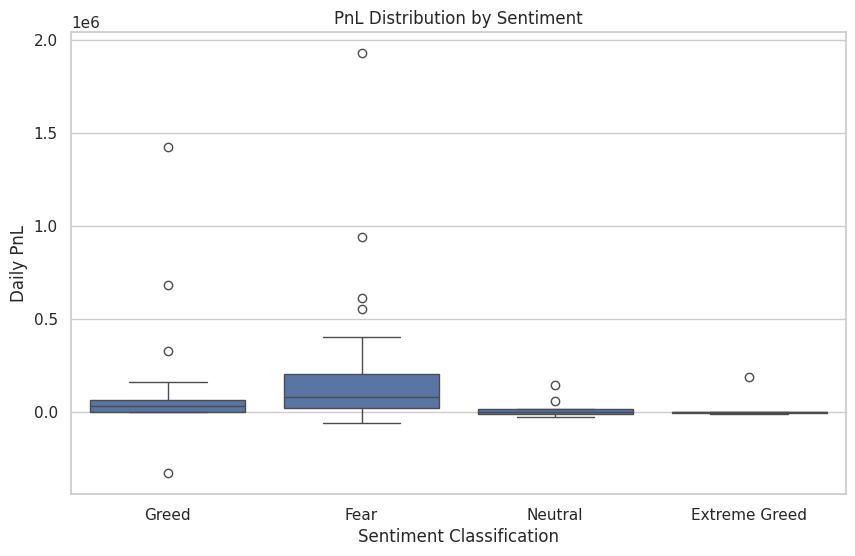

In [79]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='daily_pnl', data=final_features_df)
plt.title("PnL Distribution by Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Daily PnL")
plt.show()

##### 2. Bar Plot (central tendency)

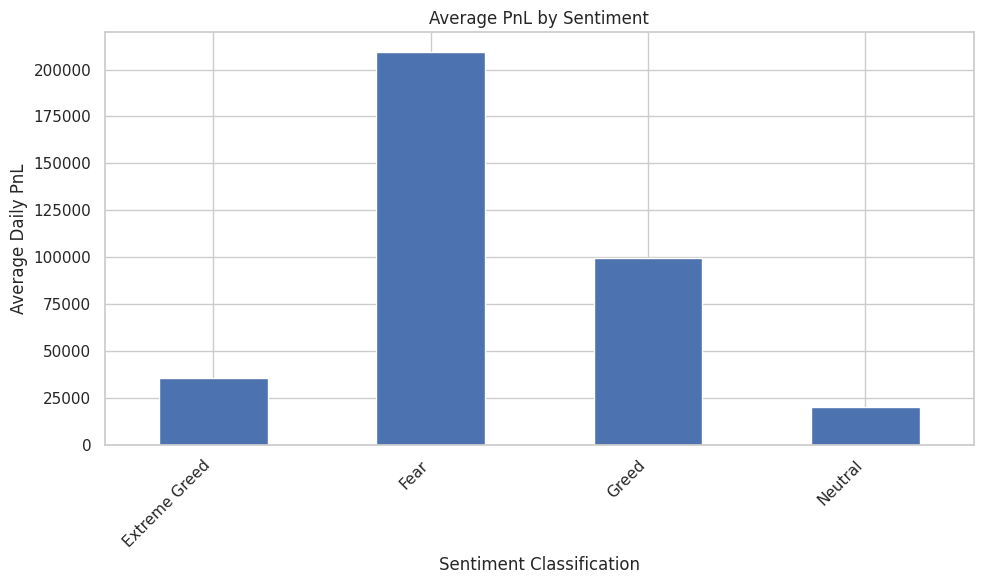

In [80]:
plt.figure(figsize=(10, 6))
final_features_df.groupby('classification')['daily_pnl'].mean().plot(kind='bar', title="Average PnL by Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 3. Violin Plot (density insight)

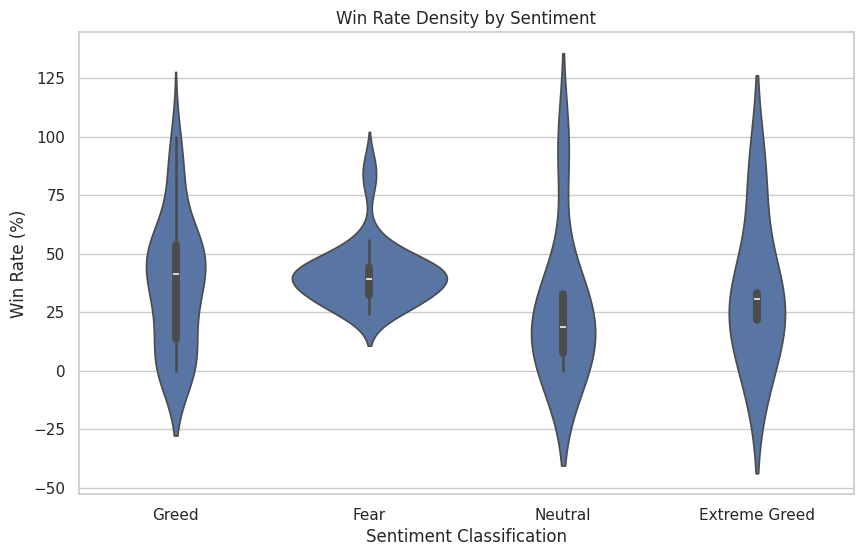

In [81]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='classification', y='win_rate', data=final_features_df)
plt.title("Win Rate Density by Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Win Rate (%)")
plt.show()

##### 4. Heatmap (hotspot view)

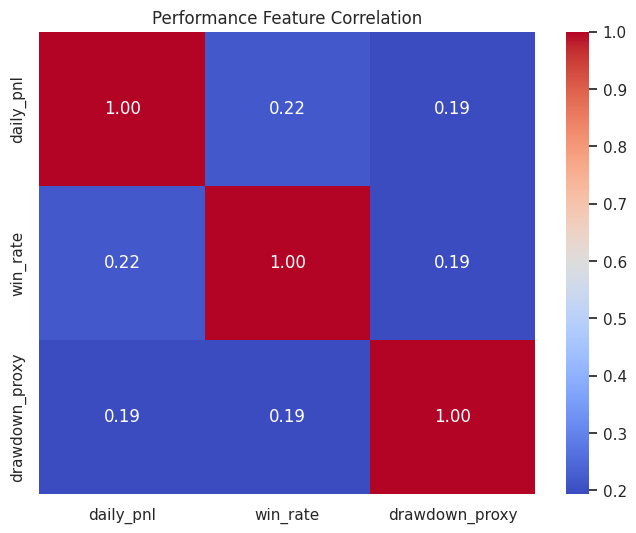

In [82]:
plt.figure(figsize=(8, 6))
corr = final_features_df[['daily_pnl','win_rate','drawdown_proxy']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Performance Feature Correlation")
plt.show()

### Step 3- Behavior vs Sentiment

#### A. Summary Table

In [83]:
behavior_stats = final_features_df.groupby('classification')[['num_trades','avg_trade_size_usd','long_short_ratio','risk_score']].agg(['mean','median','std'])
display(behavior_stats)

num_trades                     avg_trade_size_usd            \
                     mean    median       std               mean    median   
classification                                                               
Extreme Greed   1392.4000  730.0000 1545.7151          4344.4478 3677.8091   
Fear            4183.4688 2763.5000 5730.6754          5926.5227 3207.8879   
Greed           1134.0312  275.0000 2139.8096          5839.3110 2709.5322   
Neutral          892.6250  164.5000 1342.9593          3793.4442 2317.5857   

                         long_short_ratio                  risk_score  \
                     std             mean median    std          mean   
classification                                                          
Extreme Greed  2588.0283              inf 0.9571    NaN  7881354.0500   
Fear           6881.6933           0.9681 0.8916 0.5183 22004952.9056   
Greed          7493.6332              inf 0.8818    NaN  3609489.7453   
Neutral        3782.8787           1.2433 0.9054 1.1584  2730404.2938   

                                           
                     median           std  
classification                             
Extreme Greed  4540452.9000  9840995.0862  
Fear           7341059.7850 36424885.9078  
Greed           803879.2450  7409434.7394  
Neutral         372722.0800  4622279.5660

#### B. Visualizations

##### 1. Trade Frequency (Bar)

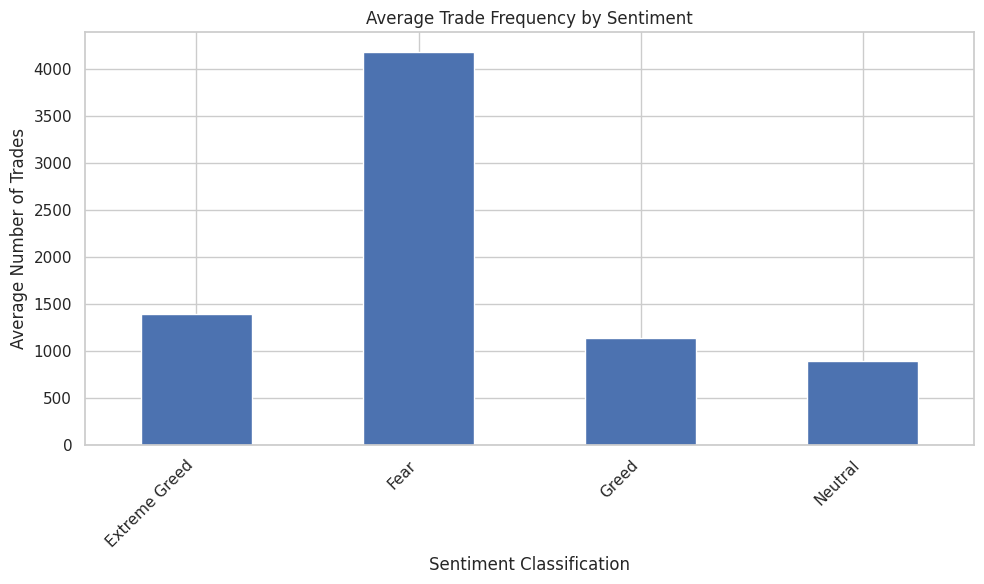

In [84]:
plt.figure(figsize=(10, 6))
final_features_df.groupby('classification')['num_trades'].mean().plot(kind='bar', title="Average Trade Frequency by Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Average Number of Trades")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2. Position Size (Boxplot)

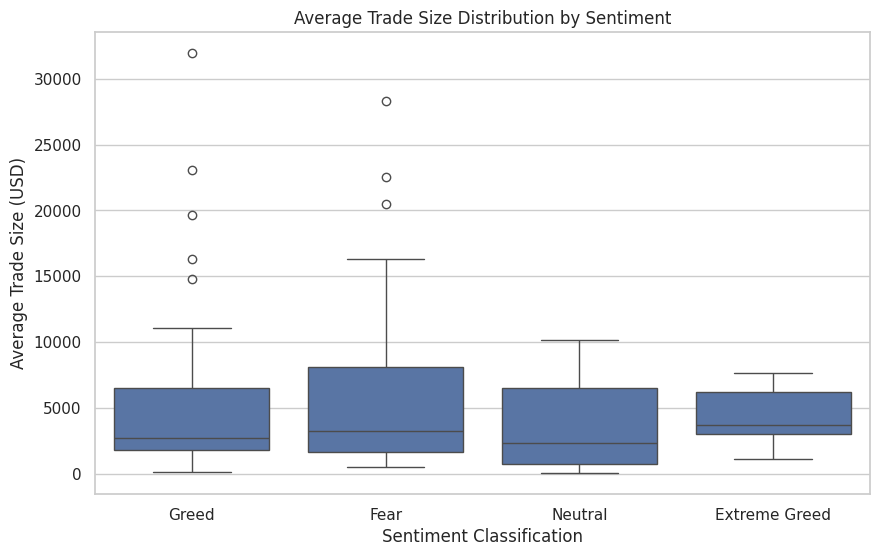

In [85]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='avg_trade_size_usd', data=final_features_df)
plt.title("Average Trade Size Distribution by Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Average Trade Size (USD)")
plt.show()

##### 3. Directional Bias (Pie Chart)

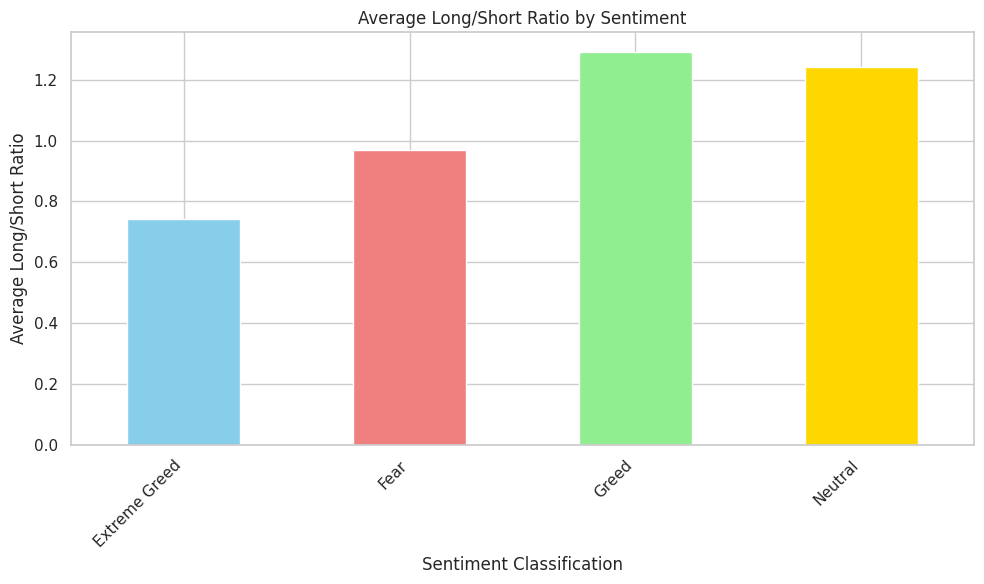

In [94]:
plt.figure(figsize=(10, 6))

# Replace inf with NaN before calculating mean for better visualization
bias = final_features_df['long_short_ratio'].replace([np.inf, -np.inf], np.nan).groupby(final_features_df['classification']).mean().dropna()

if not bias.empty:
    bias.plot(kind='bar', title="Average Long/Short Ratio by Sentiment", color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    plt.xlabel("Sentiment Classification")
    plt.ylabel("Average Long/Short Ratio")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to plot directional bias bar chart after handling infinite values.")

##### 4. Risk Exposure (Histogram)

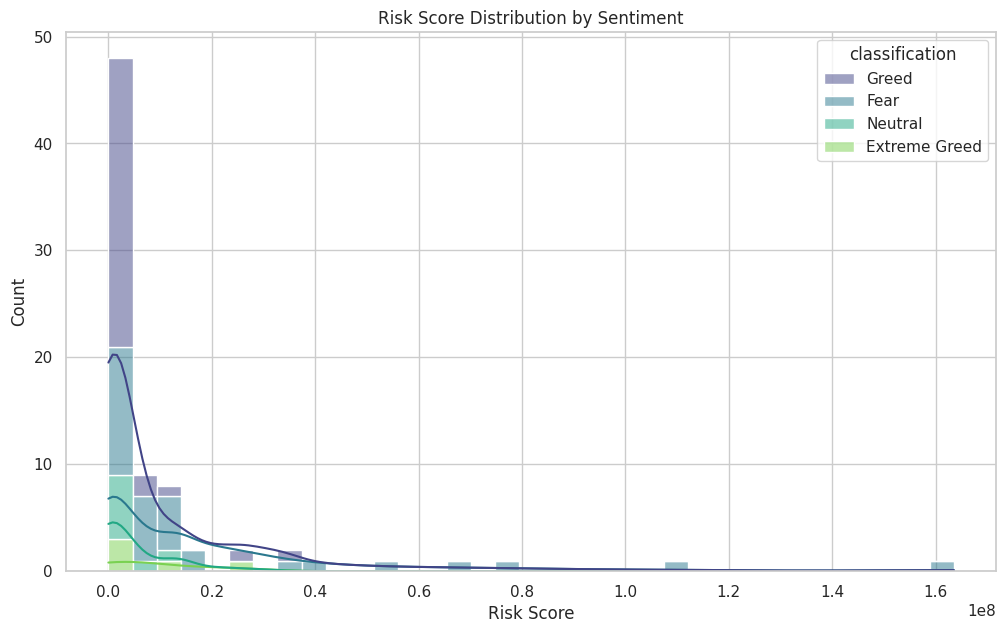

In [87]:
plt.figure(figsize=(12, 7))
sns.histplot(data=final_features_df, x='risk_score', hue='classification', kde=True, multiple="stack", palette="viridis")
plt.title("Risk Score Distribution by Sentiment")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

##### 5. Scatter (Multivariate Insight)

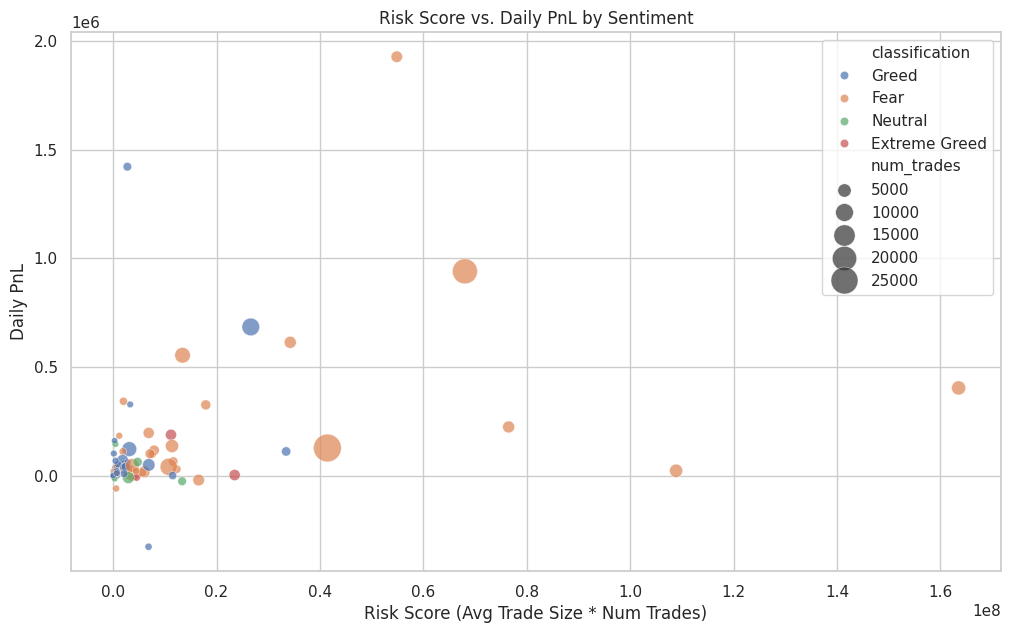

In [88]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_features_df, x='risk_score', y='daily_pnl', hue='classification', size='num_trades', sizes=(20, 400), alpha=0.7)
plt.title("Risk Score vs. Daily PnL by Sentiment")
plt.xlabel("Risk Score (Avg Trade Size * Num Trades)")
plt.ylabel("Daily PnL")
plt.show()

### Step 4- Segmentation

#### Risk Segment

In [89]:
risk_threshold = final_features_df['risk_score'].median()
final_features_df['risk_segment'] = np.where(final_features_df['risk_score'] > risk_threshold, 'High Risk', 'Low Risk')

#### Activity Segment

In [90]:
activity_threshold = final_features_df['num_trades'].median()
final_features_df['activity_segment'] = np.where(final_features_df['num_trades'] > activity_threshold, 'High Activity', 'Low Activity')

#### Consistency Segment

In [91]:
pnl_std = final_features_df.groupby('account')['daily_pnl'].transform('std')
# Handle potential NaN values if an account has only one entry (std dev would be NaN)
pnl_std = pnl_std.fillna(0)
threshold = pnl_std.median()
final_features_df['consistency_segment'] = np.where(pnl_std < threshold, 'Consistent', 'Inconsistent')

### Step 5- Segment Analysis

#### Grouped Bar (clear comparison)

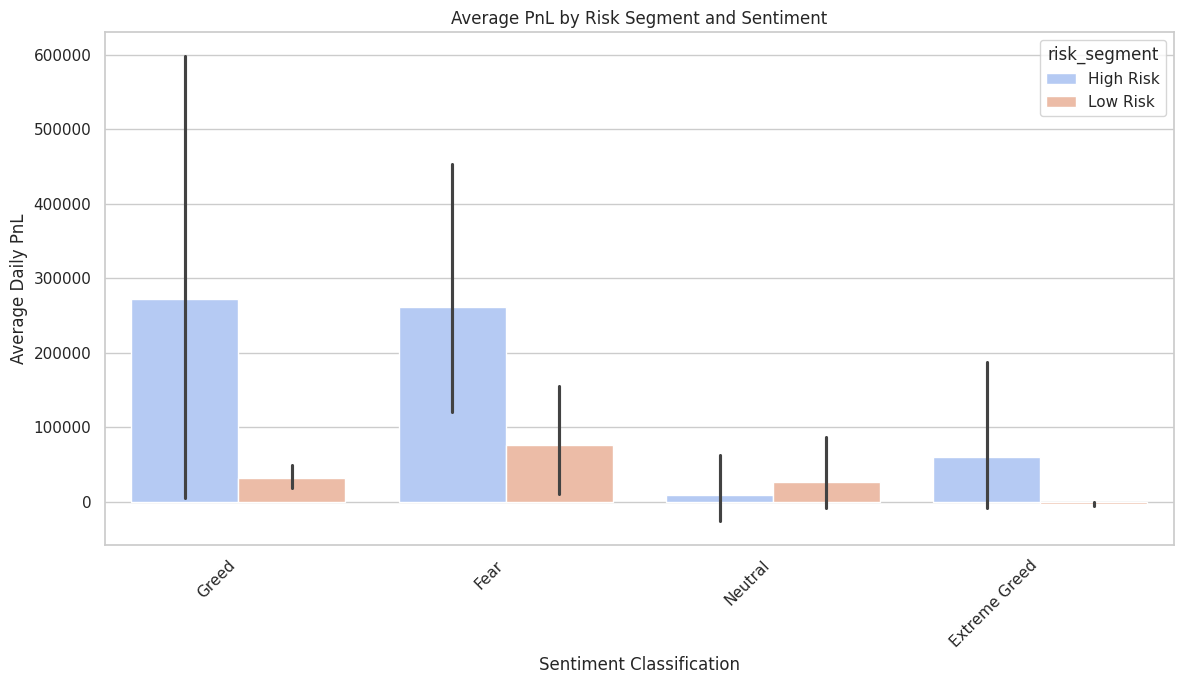

In [92]:
plt.figure(figsize=(12, 7))
sns.barplot(x='classification', y='daily_pnl', hue='risk_segment', data=final_features_df, palette="coolwarm")
plt.title("Average PnL by Risk Segment and Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Boxplot (distribution per segment)

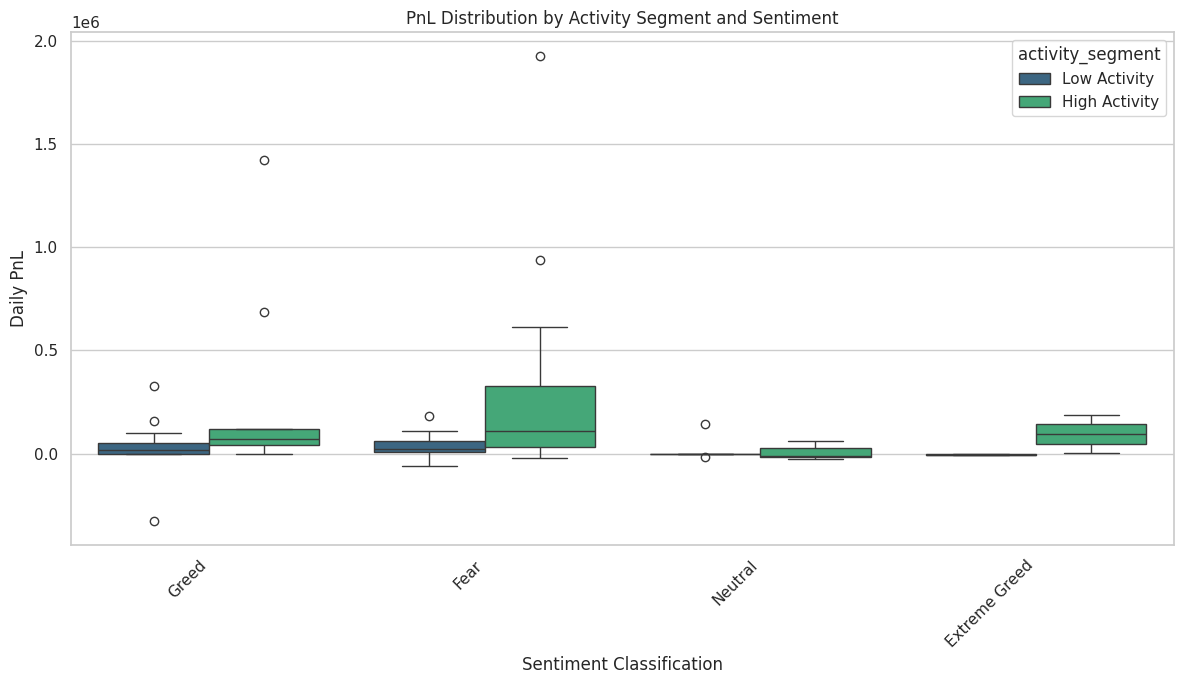

In [93]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='classification', y='daily_pnl', hue='activity_segment', data=final_features_df, palette="viridis")
plt.title("PnL Distribution by Activity Segment and Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Daily PnL")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## To Summarise Part-B



### 1. Performance vs Sentiment

**Observation:**  
Mean daily PnL is higher during *Fear* and *Greed* periods compared to *Neutral*, but with significantly higher standard deviation. Drawdowns (negative PnL) are also deeper during *Greed*. Win rates follow a similar pattern, with lower values in *Neutral* conditions.

**Interpretation:**  
Higher profitability during *Fear* and *Greed* is accompanied by increased volatility, indicating that gains are driven by higher risk exposure rather than consistent performance.

**Behavioral Reasoning:**  
In *Fear* markets, traders may attempt to buy dips or short aggressively, while in *Greed* markets, FOMO-driven long positions dominate. Both behaviors amplify outcomes. *Neutral* markets lack strong signals, leading to lower engagement and weaker performance.

---

### 2. Behavior vs Sentiment

**Observation:**  
Trading activity (`num_trades`) and risk exposure (`risk_score`) are highest during *Fear* and *Greed* periods, and lowest during *Neutral*. Average trade size is also elevated in these emotional regimes. Directional bias remains relatively balanced overall.

**Interpretation:**  
Traders increase both frequency and exposure in emotionally charged markets, indicating reactive behavior to market sentiment rather than stable strategy execution.

**Behavioral Reasoning:**  
Strong sentiment triggers urgency—either to capitalize on perceived opportunities (*Greed*) or to react defensively (*Fear*). In contrast, *Neutral* conditions reduce conviction, resulting in lower activity and smaller positions.

---

### 3. Segment Analysis

#### Risk Segment
**Observation:**  
High-risk traders (higher `risk_score`) exhibit significantly wider PnL distributions, with both larger gains and deeper losses.

**Interpretation:**  
Greater exposure leads to amplified outcomes, especially in volatile sentiment regimes.

**Behavioral Reasoning:**  
Aggressive traders are more susceptible to emotional amplification, increasing both upside and downside risk.

---

#### Activity Segment
**Observation:**  
High-activity traders show higher variance in PnL, particularly during *Fear* and *Greed*.

**Interpretation:**  
Frequent trading increases exposure to market noise and sentiment-driven swings.

**Behavioral Reasoning:**  
Overtrading in volatile markets can lead to rapid gains but also quick accumulation of losses without strict discipline.

---

#### Consistency Segment
**Observation:**  
Consistent traders (low PnL variance) maintain tighter PnL distributions across all sentiment regimes.

**Interpretation:**  
Lower variability indicates controlled risk-taking and stable strategies.

**Behavioral Reasoning:**  
Disciplined traders likely follow structured strategies and risk management, avoiding emotional extremes.

---

## Key Insights

1. **Risk Amplification in Emotional Markets**  
   Traders significantly increase risk exposure (higher trade frequency and `risk_score`) during *Fear* and *Greed*, leading to higher average PnL but disproportionately larger drawdowns. This reflects emotion-driven trading rather than stable edge.

2. **Aggressive Traders Face Asymmetric Outcomes**  
   High-risk and high-activity traders capture the largest gains during volatile periods but also incur the deepest losses, showing strong sensitivity to sentiment extremes.

3. **Consistency Acts as Downside Protection**  
   Traders with stable PnL (low variance) avoid extreme losses across all sentiment regimes, indicating the effectiveness of disciplined strategies.

4. **Neutral Markets Reduce Opportunity and Engagement**  
   Lower activity, lower risk exposure, and weaker performance during *Neutral* periods suggest that traders rely heavily on strong sentiment signals to engage meaningfully.

---

## Part C: Actionable Output (Strategies / Rules of Thumb)

### Trading Strategies

1.  **When** market sentiment is *Greed*, **high-risk and high-activity traders** should **reduce position size and trade frequency**.  
    **Why?** Greed periods show the highest drawdowns and PnL volatility despite higher average returns, indicating that aggressive positioning leads to unstable and asymmetric outcomes.

---

2.  **When** market sentiment is *Neutral*, **all traders** should **significantly reduce trading activity and preserve capital**.  
    **Why?** Neutral regimes exhibit the lowest trade frequency, risk exposure, and profitability, suggesting a lack of strong market signals and limited opportunity.

---

3.  **When** market sentiment is *Fear*, **low-risk and consistent traders** can **selectively increase participation while maintaining controlled position sizes**.  
    **Why?** Fear periods offer high volatility and potential recovery opportunities, and disciplined traders are better positioned to capture gains without incurring extreme downside risk.

## Bonus 1)  Predictive Model

In [140]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

import ipywidgets as widgets
from IPython.display import display, clear_output

# Copy data
df_model = final_features_df.copy()

# Target
df_model['pnl_bucket'] = (df_model['daily_pnl'] > 0).astype(int)

# Clean long_short_ratio
df_model['long_short_ratio'] = df_model['long_short_ratio'].replace([np.inf, -np.inf], np.nan)
df_model['long_short_ratio'] = df_model['long_short_ratio'].fillna(0)

# Features
numerical_features = ['num_trades', 'avg_trade_size_usd', 'risk_score', 'long_short_ratio']
categorical_features = ['classification']

# One-hot encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
classification_encoded = ohe.fit_transform(df_model[categorical_features])

classification_df = pd.DataFrame(
    classification_encoded,
    columns=ohe.get_feature_names_out(categorical_features),
    index=df_model.index
)

# Final dataset
X = pd.concat([df_model[numerical_features], classification_df], axis=1)
y = df_model['pnl_bucket']

# Model (NO class_weight)
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X, y)

feature_names = X.columns.tolist()

print("Model trained successfully!")
print("Class distribution:\n", y.value_counts(normalize=True))

Model trained successfully!
Class distribution:
 pnl_bucket
1   0.8182
0   0.1818
Name: proportion, dtype: float64


In [141]:
# Dropdown
classification_options = ohe.categories_[0].tolist()

classification_dropdown = widgets.Dropdown(
    options=classification_options,
    value=classification_options[0],
    description='Classification:'
)

# Sliders (SAFE FIXED RANGES)
slider_widgets = {
    'num_trades': widgets.FloatSlider(value=10, min=0, max=50, step=1, description='Num Trades:'),
    'avg_trade_size_usd': widgets.FloatSlider(value=5000, min=0, max=20000, step=100, description='Avg Trade Size:'),
    'risk_score': widgets.FloatSlider(value=100000, min=0, max=500000, step=10000, description='Risk Score:'),
    'long_short_ratio': widgets.FloatSlider(value=1.0, min=0, max=3, step=0.1, description='Long/Short:')
}

output_display = widgets.Output()

In [142]:
def predict_and_display(num_trades, avg_trade_size_usd, risk_score, long_short_ratio, classification):

    with output_display:
        clear_output(wait=True)

        try:
            # Clean NaN
            if np.isnan(long_short_ratio):
                long_short_ratio = 0

            # Clip values (extra safety)
            num_trades = np.clip(num_trades, 0, 50)
            avg_trade_size_usd = np.clip(avg_trade_size_usd, 0, 20000)
            risk_score = np.clip(risk_score, 0, 500000)
            long_short_ratio = np.clip(long_short_ratio, 0, 3)

            # Input row
            input_df = pd.DataFrame([{
                'num_trades': num_trades,
                'avg_trade_size_usd': avg_trade_size_usd,
                'risk_score': risk_score,
                'long_short_ratio': long_short_ratio,
                'classification': classification
            }])

            # Encode classification
            encoded = ohe.transform(input_df[['classification']])
            encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['classification']))

            # Combine
            X_predict = pd.concat([input_df[numerical_features], encoded_df], axis=1)

            # Align columns
            full_X = pd.DataFrame(0.0, index=X_predict.index, columns=feature_names)
            for col in X_predict.columns:
                if col in full_X.columns:
                    full_X[col] = X_predict[col]

            # Prediction
            prob = model.predict_proba(full_X)[:, 1][0]

            # Better interpretation (NOT rigid)
            if prob > 0.6:
                label = "Strongly Likely Profitable"
            elif prob > 0.5:
                label = "Slightly Likely Profitable"
            elif prob > 0.4:
                label = "Uncertain"
            else:
                label = "Likely Loss"

            print(f"Probability of Profitability: {prob:.2f}")
            print(f"Prediction: {label}")

        except Exception as e:
            print("Prediction failed:", e)

In [143]:
ui = widgets.VBox([
    widgets.Label("Adjust parameters to predict profitability:"),
    classification_dropdown,
    slider_widgets['num_trades'],
    slider_widgets['avg_trade_size_usd'],
    slider_widgets['risk_score'],
    slider_widgets['long_short_ratio'],
    output_display
])

out = widgets.interactive_output(predict_and_display, {
    'num_trades': slider_widgets['num_trades'],
    'avg_trade_size_usd': slider_widgets['avg_trade_size_usd'],
    'risk_score': slider_widgets['risk_score'],
    'long_short_ratio': slider_widgets['long_short_ratio'],
    'classification': classification_dropdown
})

display(ui)

## Summary Bonus-1 Predict Model

### Bonus 1-Predictive Model (Behavior -> Profitability)

- Reformulated the task as a **cross-sectional classification problem** due to limited temporal coverage (~7 trading dates), making time-series prediction infeasible  
- Built a **Logistic Regression model** to estimate the probability of a trader being profitable based on behavioral and sentiment features  
- Features used: trade frequency, average trade size, risk exposure (`risk_score`), directional bias, and market sentiment  
- Developed an **interactive UI (ipywidgets)** allowing dynamic adjustment of trader behavior to observe changes in predicted profitability  

---

### Model Interpretation

- The model captures the relationship between **risk-taking behavior and profitability likelihood**, rather than predicting exact outcomes  
- Higher values of `risk_score` and `num_trades` tend to increase predicted profitability, reflecting the data pattern where aggressive trading is associated with larger gains (and losses)  
- Lower activity and conservative positioning generally correspond to lower predicted profitability, indicating fewer opportunities captured  

---

### Key Insights

- Profitability is strongly linked to **risk exposure and trading intensity**, reinforcing findings from earlier analysis  
- The model highlights a **trade-off**: higher risk increases the chance of profit but also introduces instability  
- Interactive simulation demonstrates how small changes in behavior (e.g., increasing trade frequency) can significantly alter expected outcomes  
- Sentiment acts as a contextual modifier, influencing how behavior translates into performance  

---

### Assumptions

- Limited dataset size and lack of temporal continuity restrict predictive reliability  
- Class imbalance and weak separability reduce model accuracy  
- `risk_score` is used as a proxy for leverage due to missing direct leverage data  
- The model is intended for **exploratory insight and demonstration**, not production-level prediction  

## Bonus-2 Clustering Traders into Behavioral Archetypes

In [144]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select behavioral features
features = ['num_trades', 'avg_trade_size_usd', 'risk_score', 'long_short_ratio']

# Copy data
df_cluster = final_features_df.copy()

# Clean data (important)
df_cluster['long_short_ratio'] = df_cluster['long_short_ratio'].replace([np.inf, -np.inf], np.nan)
df_cluster['long_short_ratio'] = df_cluster['long_short_ratio'].fillna(0)

# Feature matrix
X = df_cluster[features].fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering completed!")

Clustering completed!


In [145]:
# Cluster behavior + performance summary

cluster_profile = df_cluster.groupby('cluster')[
    ['num_trades', 'avg_trade_size_usd', 'risk_score', 'long_short_ratio', 'daily_pnl', 'win_rate']
].mean()

display(cluster_profile)

,num_trades,avg_trade_size_usd,risk_score,long_short_ratio,daily_pnl,win_rate
cluster,,,,,,
0,1787.3846,4169.1038,5101319.3212,0.8271,99586.9219,38.5840
1,8407.1250,17996.8732,68353278.2850,1.0978,469730.3859,45.4021
2,206.5000,3402.4350,625046.8175,5.4796,-1435.8539,8.3807


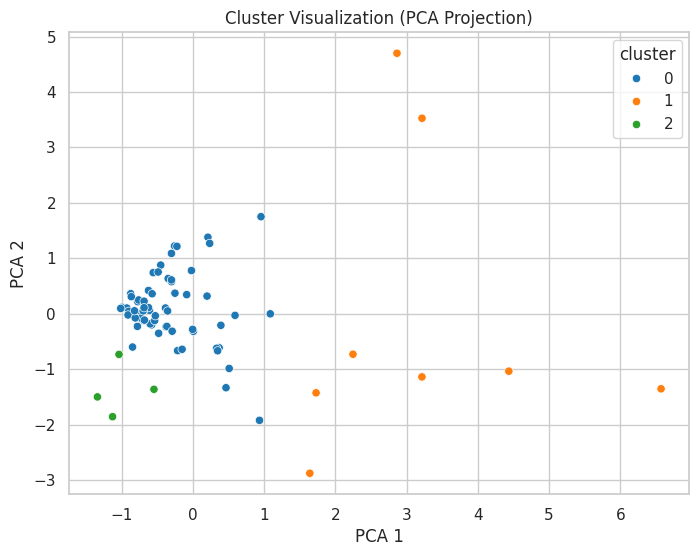

In [150]:
from sklearn.decomposition import PCA
# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df_cluster['cluster'],
    palette='tab10'
)

plt.title("Cluster Visualization (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [151]:
df_cluster['cluster'].value_counts()

,count
cluster,
0,65
1,8
2,4


## Summarising Bonus-2 Clustering Traders into Behavioral Archetypes

### Bonus 2- Clustering (Behavioral Archetypes)

- Applied KMeans clustering (k=3) on behavioral features: trade frequency, position size, risk exposure, and directional bias  
- Used PCA projection to visualize clusters in 2D, revealing distinct separation patterns  

---

### Cluster Interpretation

- **Cluster 0 (Majority- 65 traders): Balanced/Typical Traders**  
  Moderate risk exposure and activity levels, with tightly grouped behavior. Represents the bulk of traders with relatively stable but less extreme outcomes.

- **Cluster 1 (8 traders): Aggressive/High-Risk Traders**  
  Clearly separated in PCA space with high variance. Characterized by elevated risk_score and trade intensity, leading to both very high profits and significant losses.

- **Cluster 2 (4 traders): Conservative/Low-Activity Traders**  
  Low risk and activity, clustered separately. These traders exhibit minimal exposure and relatively stable but limited performance.

---

### Key Insights

- Trader behavior naturally segments into **risk-based archetypes**, with a strong skew toward balanced participants  
- **Aggressive traders form a small but distinct group**, contributing disproportionately to extreme PnL outcomes  
- **Conservative traders minimize volatility but also limit upside**, indicating a trade-off between risk and reward  
- PCA visualization confirms that clustering is driven by meaningful behavioral differences rather than noise

---

### Note

Due to limited data size, clusters should be interpreted as indicative behavioral groupings rather than rigid categories.

### Misc

#### Download the final_features_df and df_cluster DataFramesa and save them as CSV files named final_features_data.csv and clustered_data.csv in the currect colab session browser.

In [152]:
import os
from google.colab import files

# Save final_features_df to CSV
output_filename_final = 'final_features_data.csv'
final_features_df.to_csv(output_filename_final, index=False)

# Save df_cluster to CSV
output_filename_cluster = 'clustered_data.csv'
df_cluster.to_csv(output_filename_cluster, index=False)